# TP optimisation — Exercice 1 : régression (OLS, ridge, noyau RBF)


In [13]:
import os
print("Dossier de travail (cwd) :", os.getcwd())

Dossier de travail (cwd) : c:\Users\lenovo\Desktop\HADRI


## 1. Configuration (modifiable)
Les fichiers de données doivent être dans `data/` (voir notebook `00_donnees`).

In [ ]:
from pathlib import Path
DATA_DIR = next((str(p) for p in [Path("data"), Path("../data")] if p.exists()), "data")
print("Données lues dans :", os.path.abspath(DATA_DIR))
from types import SimpleNamespace
args = SimpleNamespace(data=DATA_DIR, out="results", epochs=500, bs=32)   

Données lues dans : c:\Users\lenovo\Desktop\HADRI\data


## 2. Code commun : les 7 optimiseurs (NumPy), vérification de gradient, utilitaires

In [ ]:
"""Outils communs aux 3 exercices : les 7 méthodes d'optimisation (NumPy pur),
vérification de gradient, chargement de données, tableaux LaTeX, ACP."""
import os, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

METHODS = ["GD", "GD+recherche", "SGD", "Momentum", "AdaGrad", "RMSprop", "Adam"]
COLORS = {"GD": "tab:blue", "GD+recherche": "tab:cyan", "SGD": "tab:orange",
          "Momentum": "tab:green", "AdaGrad": "tab:red", "RMSprop": "tab:purple",
          "Adam": "black", "Lloyd (réf.)": "tab:brown"}
FULL_BATCH = ("GD", "GD+recherche")          
MU = RHO = B1 = 0.9
B2 = 0.999
EPS = 1e-8
SEEDS = [42, 123, 2024]



def line_search_numeric(loss_fn, theta, g, eta_max, n=12):
    """Recherche directionnelle bornée et approchée : on teste eta_max/2^k
    (k=0..n-1) le long de -g et on garde le pas de plus petite perte."""
    best_eta, best = eta_max / 2 ** (n - 1), np.inf
    l0, calls, eta = loss_fn(theta), 1, eta_max
    best = l0
    found = False
    for _ in range(n):
        l = loss_fn(theta - eta * g)
        calls += 1
        if np.isfinite(l) and l < best:
            best, best_eta, found = l, eta, True
        eta /= 2
    return best_eta, calls


def run_optimizer(method, theta0, grad_fn, loss_fn, n, eta, epochs, batch_size, seed,
                  eval_fn, select_key, hvp=None, eta_max=5.0):
    """Boucle d'entraînement commune.
    grad_fn(theta, idx) et loss_fn(theta, idx=None) : idx=None <=> tout le jeu.
    eval_fn(theta) -> dict de métriques (contient select_key, à minimiser).
    hvp(g) : produit Hessienne-vecteur (pas exact pour les objectifs quadratiques)."""
    rng = np.random.default_rng(seed)
    theta = theta0.copy()
    m = np.zeros_like(theta); s = np.zeros_like(theta); v = np.zeros_like(theta)
    t = 0
    cnt = dict(updates=0, grad_calls=0, loss_calls=0, hvp_calls=0)
    hist, ttrain, diverged = [], 0.0, False
    best_val, best_theta, best_ep = np.inf, theta.copy(), 0
    with np.errstate(all="ignore"):
        for ep in range(1, epochs + 1):
            t0 = time.perf_counter()
            if method in FULL_BATCH:
                batches = [None]
            else:
                perm = rng.permutation(n)
                batches = [perm[i:i + batch_size] for i in range(0, n, batch_size)]
            for idx in batches:
                g = grad_fn(theta, idx); cnt["grad_calls"] += 1
                t += 1; cnt["updates"] += 1
                if method == "GD" or method == "SGD":
                    theta = theta - eta * g
                elif method == "GD+recherche":
                    step = None
                    if hvp is not None:
                        d = g @ hvp(g); cnt["hvp_calls"] += 1
                        if d > 0:
                            step = (g @ g) / d          
                    if step is None:
                        step, c = line_search_numeric(loss_fn, theta, g, eta_max)
                        cnt["loss_calls"] += c
                    theta = theta - step * g
                elif method == "Momentum":
                    v = MU * v + g
                    theta = theta - eta * v
                elif method == "AdaGrad":
                    s = s + g * g
                    theta = theta - eta * g / (np.sqrt(s) + EPS)
                elif method == "RMSprop":
                    s = RHO * s + (1 - RHO) * g * g
                    theta = theta - eta * g / (np.sqrt(s) + EPS)
                elif method == "Adam":
                    m = B1 * m + (1 - B1) * g
                    s = B2 * s + (1 - B2) * g * g
                    mh, sh = m / (1 - B1 ** t), s / (1 - B2 ** t)
                    theta = theta - eta * mh / (np.sqrt(sh) + EPS)
                else:
                    raise ValueError(method)
            ttrain += time.perf_counter() - t0        
            if not np.isfinite(theta).all():
                diverged = True
                break
            met = dict(eval_fn(theta))
            cnt["loss_calls"] += 2   
            met.update(epoch=ep, time=ttrain, updates=cnt["updates"],
                       grad_calls=cnt["grad_calls"], loss_calls=cnt["loss_calls"])
            hist.append(met)
            if met[select_key] < best_val:
                best_val, best_theta, best_ep = met[select_key], theta.copy(), ep
    return dict(hist=hist, best_value=(np.inf if diverged else best_val),
                best_theta=best_theta, best_epoch=best_ep, time=ttrain,
                diverged=diverged, **cnt)


def gradcheck(loss_fn, grad_fn, theta, ncoord=8, h=1e-5, seed=0):
    """Erreur relative max entre gradient analytique et différences finies
    centrales (h = 1e-5) sur quelques coordonnées (theta en float64)."""
    rng = np.random.default_rng(seed)
    g = grad_fn(theta, None)
    cand = np.where(np.abs(g) > 1e-3 * np.abs(g).max())[0]   
    cand = cand if len(cand) else np.arange(theta.size)  
    idxs = rng.choice(cand, min(ncoord, len(cand)), replace=False)
    errs = []
    for i in idxs:
        e = np.zeros_like(theta); e[i] = h
        num = (loss_fn(theta + e, None) - loss_fn(theta - e, None)) / (2 * h)
        errs.append(abs(num - g[i]) / max(1e-12, abs(num) + abs(g[i])))
    return float(max(errs))


def split_of(df):
    def f(v):
        v = str(v).lower()
        return "train" if v.startswith("tr") else ("val" if v.startswith("va") else "test")
    return df["split"].map(f).values


def find_col(df, candidates, default_last=True):
    for c in candidates:
        if c in df.columns:
            return c
    cols = [c for c in df.columns if c != "split"]
    return cols[-1] if default_last else None


def standardize(X, tr):
    mu, sd = X[tr].mean(0), X[tr].std(0)
    sd = np.where(sd == 0, 1.0, sd)
    return (X - mu) / sd, mu, sd


def pca2(X_fit, X_list):
    """ACP 2D par SVD (ajustée sur X_fit). Retourne les projections de X_list."""
    mu = X_fit.mean(0)
    _, _, Vt = np.linalg.svd(X_fit - mu, full_matrices=False)
    return [(X - mu) @ Vt[:2].T for X in X_list]


def ensure_dirs(out):
    os.makedirs(os.path.join(out, "figures"), exist_ok=True)


def savefig(fig, out, name):
    fig.tight_layout()
    fig.savefig(os.path.join(out, "figures", name + ".png"), dpi=130)
    plt.close(fig)


def ms(vals, dec=3):
    v = np.asarray(vals, float)
    return f"{v.mean():.{dec}f} $\\pm$ {v.std():.{dec}f}"


def tex_escape(s):
    s = str(s).replace("_", "\\_").replace("%", "\\%").replace("&", "\\&").replace("#", "\\#")
    for u, m in {"η": "$\\eta$", "λ": "$\\lambda$", "σ": "$\\sigma$", "τ": "$\\tau$"}.items():
        s = s.replace(u, m)
    return s


def df_to_latex(df, path):
    lines = ["\\resizebox{\\textwidth}{!}{%", "\\begin{tabular}{" + "l" * len(df.columns) + "}",
             "\\hline", " & ".join(tex_escape(c) for c in df.columns) + " \\\\", "\\hline"]
    for _, r in df.iterrows():
        lines.append(" & ".join(tex_escape(x) for x in r) + " \\\\")
    lines += ["\\hline", "\\end{tabular}}"]
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


def load_npz_images(path, fast=None):
    d = np.load(path)
    out = {}
    for k in ["train", "val", "test"]:
        x = d["x_" + k].reshape(len(d["x_" + k]), -1)
        y = d["y_" + k].astype(np.int64).ravel()
        if fast and k == "train":
            x, y = x[:fast], y[:fast]
        out[k] = (x, y)
    return out

FASHION = ["T-shirt", "Pantalon", "Pull", "Robe", "Manteau", "Sandale",
           "Chemise", "Basket", "Sac", "Bottine"]

import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

## Définitions (modèles, gradients, données)

In [ ]:
"""Exercice 1 : OLS, ridge et ridge à noyau RBF, avec les 7 optimiseurs."""
import os

ensure_dirs(args.out)

DATASETS = {"nonlinear": "regression_nonlinear.csv", "diabetes": "regression_diabetes.csv"}
GRIDS = {"GD": 10 ** np.arange(-4, 0.1, 0.5), "SGD": 10 ** np.arange(-4, 0.1, 0.5),
         "Momentum": 10 ** np.arange(-5, -0.9, 0.5), "AdaGrad": 10 ** np.arange(-3, 0.1, 0.5),
         "RMSprop": 10 ** np.arange(-4, -0.4, 0.5), "Adam": 10 ** np.arange(-4, -0.4, 0.5),
         "GD+recherche": [None]}


def load_reg(path):
    df = pd.read_csv(path); sp = split_of(df)
    feats = [c for c in df.columns if c not in ("y", "split")]
    X, y = df[feats].values.astype(float), df["y"].values.astype(float)
    tr, va, te = sp == "train", sp == "val", sp == "test"
    Xs, _, _ = standardize(X, tr)                       
    ym, ys = y[tr].mean(), y[tr].std()
    return dict(Xtr=Xs[tr], Xva=Xs[va], Xte=Xs[te], ytr=(y[tr] - ym) / ys,
                yva=y[va], yte=y[te], ym=ym, ys=ys, feats=feats, df=df, tr=tr)


def add1(X): return np.c_[np.ones(len(X)), X]


class Linear:
    """J = ||Xw-y||^2/(2n) + lam/2 w^T P w ; biais non pénalisé."""
    def __init__(s, D, lam):
        s.X = {"tr": add1(D["Xtr"]), "va": add1(D["Xva"]), "te": add1(D["Xte"])}
        s.y, s.lam, s.n = D["ytr"], lam, len(D["ytr"])
        s.p = np.r_[0.0, np.ones(s.X["tr"].shape[1] - 1)]; s.dim = s.X["tr"].shape[1]
    def loss(s, w, idx=None):
        X, y = (s.X["tr"], s.y) if idx is None else (s.X["tr"][idx], s.y[idx])
        r = X @ w - y
        return r @ r / (2 * len(y)) + s.lam / 2 * (s.p * w) @ w
    def grad(s, w, idx=None):
        X, y = (s.X["tr"], s.y) if idx is None else (s.X["tr"][idx], s.y[idx])
        return X.T @ (X @ w - y) / len(y) + s.lam * s.p * w
    def hvp(s, g): return s.X["tr"].T @ (s.X["tr"] @ g) / s.n + s.lam * s.p * g
    def predict(s, w, part): return s.X[part] @ w
    def closed_form(s):
        X = s.X["tr"]
        H = X.T @ X / s.n + s.lam * np.diag(s.p)
        return np.linalg.lstsq(H, X.T @ s.y / s.n, rcond=None)[0]


def rbf(A, B, sigma):
    d = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None] - 2 * A @ B.T
    return np.exp(-np.maximum(d, 0) / (2 * sigma ** 2))


class Kernel:
    """J = ||Ka-y||^2/(2n) + lam/2 a^T K a ; K calculé avec les stats du train."""
    def __init__(s, D, lam, sigma):
        s.K = {"tr": rbf(D["Xtr"], D["Xtr"], sigma), "va": rbf(D["Xva"], D["Xtr"], sigma),
               "te": rbf(D["Xte"], D["Xtr"], sigma)}
        s.y, s.lam, s.n, s.dim = D["ytr"], lam, len(D["ytr"]), len(D["ytr"])
    def loss(s, a, idx=None):
        K = s.K["tr"]; Ka = K @ a
        KB, yB = (K, s.y) if idx is None else (K[idx], s.y[idx])
        r = KB @ a - yB
        return r @ r / (2 * len(yB)) + s.lam / 2 * a @ Ka
    def grad(s, a, idx=None):
        K = s.K["tr"]; Ka = K @ a
        if idx is None: return K @ (Ka - s.y) / s.n + s.lam * Ka
        KB = K[idx]
        return KB.T @ (KB @ a - s.y[idx]) / len(idx) + s.lam * Ka
    def hvp(s, g):
        Kg = s.K["tr"] @ g
        return s.K["tr"] @ Kg / s.n + s.lam * Kg
    def predict(s, a, part): return s.K[part] @ a
    def closed_form(s):
        return np.linalg.solve(s.K["tr"] + s.n * s.lam * np.eye(s.n), s.y)


def metrics(y, p):
    e = p - y
    return dict(mse=np.mean(e ** 2), rmse=np.sqrt(np.mean(e ** 2)), mae=np.mean(np.abs(e)),
                r2=1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum())


def val_rmse(model, th, D): return np.sqrt(np.mean((model.predict(th, "va") * D["ys"] + D["ym"] - D["yva"]) ** 2))


def select_hparams(D):
    """Choix de lambda et sigma sur la VALIDATION uniquement (solutions de contrôle)."""
    cfgs = [dict(model="OLS", lam=0.0, sigma=None)]
    best = min(((val_rmse(Linear(D, l), Linear(D, l).closed_form(), D), l) for l in 10.0 ** np.arange(-4, 1.1)))
    cfgs.append(dict(model="Ridge", lam=best[1], sigma=None))
    bk = (np.inf, None, None)
    for sg in [0.5, 1, 2, 4, 8]:
        for l in [1e-4, 1e-3, 1e-2, 1e-1]:
            m = Kernel(D, l, sg); r = val_rmse(m, m.closed_form(), D)
            if r < bk[0]: bk = (r, l, sg)
    cfgs.append(dict(model="Noyau RBF", lam=bk[1], sigma=bk[2]))
    return cfgs

## Entraînement : sélection de λ, σ, η puis 7 méthodes × 3 graines

In [ ]:
rows, gc_rows, HIST, THETA, MODELS = [], [], {}, {}, {}
for dname, fn in DATASETS.items():
    D = load_reg(os.path.join(args.data, fn))
    for cfg in select_hparams(D):
        mname = cfg["model"]
        model = Linear(D, cfg["lam"]) if mname != "Noyau RBF" else Kernel(D, cfg["lam"], cfg["sigma"])
        MODELS[(dname, mname)] = model
        w_ref = model.closed_form(); ref = val_rmse(model, w_ref, D)
        th_gc = np.random.default_rng(0).normal(0, 0.1, model.dim)
        gc_rows.append(dict(jeu=dname, modèle=mname, err_rel_max=f"{gradcheck(model.loss, model.grad, th_gc):.2e}"))
        def ev(th, model=model, D=D):
            return dict(train_loss=model.loss(th), val_rmse=val_rmse(model, th, D))
        def run(method, eta, seed):
            th0 = np.random.default_rng(seed).normal(0, 0.1, model.dim)   
            return run_optimizer(method, th0, model.grad, model.loss, model.n, eta, args.epochs,
                                 args.bs, seed, ev, "val_rmse", hvp=model.hvp)
        for method in METHODS:
            pilot = {}
            for eta in GRIDS[method]:                       
                pilot[eta] = run(method, eta, 42)
            eta = min(pilot, key=lambda e: pilot[e]["best_value"])
            for seed in SEEDS:
                r = pilot[eta] if seed == 42 else run(method, eta, seed)
                if seed == 42:
                    HIST[(dname, mname, method)] = r["hist"]; THETA[(dname, mname, method)] = r["best_theta"]
                pt = model.predict(r["best_theta"], "te") * D["ys"] + D["ym"]
                mt = metrics(D["yte"], pt)
                rows.append(dict(jeu=dname, modèle=mname, méthode=method, seed=seed,
                                 eta=eta if eta is not None else np.nan, lam=cfg["lam"],
                                 sigma=cfg["sigma"] if cfg["sigma"] else np.nan,
                                 best_epoch=r["best_epoch"], val_rmse=r["best_value"],
                                 ref_val_rmse=ref, temps=r["time"], updates=r["updates"],
                                 grad_calls=r["grad_calls"], loss_calls=r["loss_calls"],
                                 hvp_calls=r["hvp_calls"], diverge=r["diverged"], **mt))
        print(dname, mname, "terminé (lam=%s, sigma=%s)" % (cfg["lam"], cfg["sigma"]), flush=True)
    D_ = D
    globals().setdefault("DD", {})[dname] = D

nonlinear OLS terminé (lam=0.0, sigma=None)
nonlinear Ridge terminé (lam=0.0001, sigma=None)
nonlinear Noyau RBF terminé (lam=0.0001, sigma=1)
diabetes OLS terminé (lam=0.0, sigma=None)
diabetes Ridge terminé (lam=0.0001, sigma=None)
diabetes Noyau RBF terminé (lam=0.001, sigma=4)


## Tableaux (moyenne ± écart type) et vérification des gradients

In [ ]:
R = pd.DataFrame(rows); R.to_csv(os.path.join(args.out, "ex1_resultats_bruts.csv"), index=False)
pd.DataFrame(gc_rows).to_csv(os.path.join(args.out, "ex1_gradcheck.csv"), index=False)
df_to_latex(pd.DataFrame(gc_rows), os.path.join(args.out, "tab_gradcheck_ex1.tex"))

for dname in DATASETS:
    T = []
    for (mn, me), g in R[R.jeu == dname].groupby(["modèle", "méthode"], sort=False):
        f = g.iloc[0]
        T.append({"modèle": mn, "méthode": me, "η": "auto" if np.isnan(f.eta) else f"{f.eta:.1e}",
                  "λ": f"{f.lam:.0e}", "σ": "-" if np.isnan(f.sigma) else f"{f.sigma:g}",
                  "meilleure époque": f"{g.best_epoch.mean():.0f}", "RMSE val": ms(g.val_rmse),
                  "MSE test": ms(g.mse), "RMSE test": ms(g.rmse), "MAE test": ms(g.mae),
                  "R² test": ms(g.r2), "temps (s)": ms(g.temps, 2), "appels grad": f"{g.grad_calls.mean():.0f}",
                  "appels perte": f"{g.loss_calls.mean():.0f}"})
    df_to_latex(pd.DataFrame(T), os.path.join(args.out, f"tab_ex1_{dname}.tex"))
    pd.DataFrame(T).to_csv(os.path.join(args.out, f"ex1_table_{dname}.csv"), index=False)

## Figures

In [ ]:

models = ["OLS", "Ridge", "Noyau RBF"]
for dname in DATASETS:
    D = DD[dname]
    fig, ax = plt.subplots(3, 3, figsize=(15, 11))
    for i, mn in enumerate(models):
        for me in METHODS:
            h = HIST.get((dname, mn, me), [])
            if not h: continue
            ep = [x["epoch"] for x in h]
            ax[i, 0].semilogy(ep, [x["train_loss"] for x in h], color=COLORS[me], label=me)
            ax[i, 1].plot(ep, [x["val_rmse"] for x in h], color=COLORS[me], label=me)
            ax[i, 2].plot([x["time"] for x in h], [x["val_rmse"] for x in h], color=COLORS[me], label=me)
        ax[i, 0].set_title(f"{mn} : perte d'entraînement (train), graine 42"); ax[i, 0].set_xlabel("époque")
        ax[i, 1].set_title(f"{mn} : RMSE validation"); ax[i, 1].set_xlabel("époque")
        ax[i, 2].set_title(f"{mn} : RMSE validation vs temps"); ax[i, 2].set_xlabel("temps d'entraînement (s)")
        ax[i, 1].set_ylabel("RMSE (unité d'origine)")
        lo = min(min([x["val_rmse"] for x in HIST[(dname, mn, me)]] or [1e9]) for me in METHODS)
        ax[i, 1].set_ylim(lo * 0.9, lo * 2.5); ax[i, 2].set_ylim(lo * 0.9, lo * 2.5)
    ax[0, 1].legend(fontsize=7)
    fig.suptitle(f"Ex.1 – {dname} : convergence des 7 méthodes (partition train/val, graine 42)")
    savefig(fig, args.out, f"ex1_{dname}_curves")

    fig, ax = plt.subplots(2, 3, figsize=(15, 9))
    preds = {}
    for i, mn in enumerate(models):
        g = R[(R.jeu == dname) & (R.modèle == mn) & (~R.diverge)].groupby("méthode").val_rmse.mean()
        me = g.idxmin(); th = THETA[(dname, mn, me)]
        p = MODELS[(dname, mn)].predict(th, "te") * D["ys"] + D["ym"]; preds[mn] = p
        ax[0, i].scatter(D["yte"], p, s=14); lim = [min(D["yte"].min(), p.min()), max(D["yte"].max(), p.max())]
        ax[0, i].plot(lim, lim, "r--", label="diagonale y=ŷ")
        ax[0, i].set_title(f"{mn} ({me}) : test, graine 42"); ax[0, i].set_xlabel("valeur réelle"); ax[0, i].set_ylabel("valeur prédite")
        ax[0, i].legend()
        ax[1, i].hist(D["yte"] - p, bins=20); ax[1, i].set_title(f"{mn} : résidus (réel − prédit), test")
        ax[1, i].set_xlabel("résidu (unité d'origine)"); ax[1, i].set_ylabel("effectif")
    fig.suptitle(f"Ex.1 – {dname} : prédictions et résidus sur le test")
    savefig(fig, args.out, f"ex1_{dname}_pred")

    if dname == "nonlinear":
        fig, ax = plt.subplots(1, 4, figsize=(18, 4.3))
        for a_, (t, v) in zip(ax, [("Valeurs réelles (test)", D["yte"])] + [(f"Prédiction {m}", preds[m]) for m in models]):
            sc = a_.scatter(D["Xte"][:, 0], D["Xte"][:, 1], c=v, cmap="viridis", s=40, vmin=D["yte"].min(), vmax=D["yte"].max())
            a_.set_title(t); a_.set_xlabel("x1 (standardisée)"); a_.set_ylabel("x2 (standardisée)")
        fig.colorbar(sc, ax=ax, label="y")
        fig.suptitle("Ex.1 – nonlinear : fonction cible et prédictions sur le test (couleur = y)")
        fig.savefig(os.path.join(args.out, "figures", "ex1_nonlinear_surface.png"), dpi=130); plt.close(fig)
    else:
        df = D["df"][D["df"]["split"].map(lambda v: str(v).lower().startswith("tr"))]
        cols = D["feats"] + ["y"]; C = np.corrcoef(df[cols].values.T)
        fig, a_ = plt.subplots(figsize=(7.5, 6.5))
        im = a_.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
        a_.set_xticks(range(len(cols))); a_.set_xticklabels(cols, rotation=60); a_.set_yticks(range(len(cols))); a_.set_yticklabels(cols)
        fig.colorbar(im, label="corrélation de Pearson"); a_.set_title("Ex.1 – Diabetes : corrélations (train)")
        savefig(fig, args.out, "ex1_diabetes_corr")
print("Exercice 1 terminé.")

Exercice 1 terminé.


## Résultats : tableaux

In [ ]:
import glob
from IPython.display import display
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for f in sorted(glob.glob("results/ex1_table_*.csv")):
    print(f); display(pd.read_csv(f))
print("Gradcheck :"); display(pd.read_csv("results/ex1_gradcheck.csv"))

results\ex1_table_diabetes.csv


,modèle,méthode,η,λ,σ,meilleure époque,RMSE val,MSE test,RMSE test,MAE test,R² test,temps (s),appels grad,appels perte
0,OLS,GD,3.2e-01,0.0000,-,500,54.671 $\pm$ 0.036,3130.510 $\pm$ 0.727,55.951 $\pm$ 0.007,45.692 $\pm$ 0.012,0.371 $\pm$ 0.000,0.01 $\pm$ 0.00,500,1000
1,OLS,GD+recherche,auto,0.0000,-,500,54.539 $\pm$ 0.014,3133.216 $\pm$ 0.364,55.975 $\pm$ 0.003,45.736 $\pm$ 0.005,0.370 $\pm$ 0.000,0.03 $\pm$ 0.01,500,1000
2,OLS,SGD,3.2e-01,0.0000,-,224,53.281 $\pm$ 0.060,3127.572 $\pm$ 69.291,55.921 $\pm$ 0.619,46.011 $\pm$ 0.653,0.371 $\pm$ 0.014,0.15 $\pm$ 0.04,4500,1000
3,OLS,Momentum,1.0e-01,0.0000,-,243,53.126 $\pm$ 0.117,3158.562 $\pm$ 115.835,56.192 $\pm$ 1.024,46.385 $\pm$ 0.586,0.365 $\pm$ 0.023,0.13 $\pm$ 0.01,4500,1000
4,OLS,AdaGrad,1.0e+00,0.0000,-,224,53.447 $\pm$ 0.027,3041.304 $\pm$ 31.700,55.147 $\pm$ 0.287,45.212 $\pm$ 0.127,0.389 $\pm$ 0.006,0.11 $\pm$ 0.00,4500,1000
5,OLS,RMSprop,1.0e-01,0.0000,-,262,53.431 $\pm$ 0.200,3227.770 $\pm$ 202.946,56.785 $\pm$ 1.793,46.778 $\pm$ 1.099,0.351 $\pm$ 0.041,0.12 $\pm$ 0.00,4500,1000
6,OLS,Adam,1.0e-01,0.0000,-,280,53.124 $\pm$ 0.107,3022.029 $\pm$ 53.196,54.971 $\pm$ 0.484,45.305 $\pm$ 0.567,0.393 $\pm$ 0.011,0.16 $\pm$ 0.01,4500,1000
7,Ridge,GD,3.2e-01,0.0001,-,500,54.674 $\pm$ 0.036,3130.376 $\pm$ 0.713,55.950 $\pm$ 0.006,45.691 $\pm$ 0.012,0.371 $\pm$ 0.000,0.01 $\pm$ 0.00,500,1000
8,Ridge,GD+recherche,auto,0.0001,-,500,54.544 $\pm$ 0.013,3133.008 $\pm$ 0.351,55.973 $\pm$ 0.003,45.733 $\pm$ 0.005,0.370 $\pm$ 0.000,0.02 $\pm$ 0.00,500,1000
9,Ridge,SGD,3.2e-01,0.0001,-,224,53.287 $\pm$ 0.060,3127.197 $\pm$ 69.211,55.918 $\pm$ 0.618,46.009 $\pm$ 0.654,0.371 $\pm$ 0.014,0.11 $\pm$ 0.01,4500,1000


results\ex1_table_nonlinear.csv


,modèle,méthode,η,λ,σ,meilleure époque,RMSE val,MSE test,RMSE test,MAE test,R² test,temps (s),appels grad,appels perte
0,OLS,GD,1.0e+00,0.0000,-,1,1.624 $\pm$ 0.002,2.906 $\pm$ 0.008,1.705 $\pm$ 0.002,1.415 $\pm$ 0.002,0.048 $\pm$ 0.002,0.01 $\pm$ 0.00,500,1000
1,OLS,GD+recherche,auto,0.0000,-,2,1.628 $\pm$ 0.002,2.906 $\pm$ 0.012,1.705 $\pm$ 0.004,1.412 $\pm$ 0.004,0.048 $\pm$ 0.004,0.02 $\pm$ 0.01,500,1000
2,OLS,SGD,3.2e-01,0.0000,-,303,1.612 $\pm$ 0.000,2.880 $\pm$ 0.028,1.697 $\pm$ 0.008,1.374 $\pm$ 0.014,0.057 $\pm$ 0.009,0.09 $\pm$ 0.01,3500,1000
3,OLS,Momentum,1.0e-01,0.0000,-,303,1.612 $\pm$ 0.001,2.861 $\pm$ 0.010,1.691 $\pm$ 0.003,1.362 $\pm$ 0.006,0.063 $\pm$ 0.003,0.10 $\pm$ 0.02,3500,1000
4,OLS,AdaGrad,1.0e+00,0.0000,-,20,1.614 $\pm$ 0.002,2.905 $\pm$ 0.029,1.704 $\pm$ 0.008,1.378 $\pm$ 0.012,0.049 $\pm$ 0.009,0.09 $\pm$ 0.00,3500,1000
5,OLS,RMSprop,1.0e-01,0.0000,-,376,1.611 $\pm$ 0.000,2.871 $\pm$ 0.014,1.694 $\pm$ 0.004,1.366 $\pm$ 0.006,0.060 $\pm$ 0.005,0.25 $\pm$ 0.11,3500,1000
6,OLS,Adam,3.2e-01,0.0000,-,326,1.611 $\pm$ 0.000,2.875 $\pm$ 0.021,1.696 $\pm$ 0.006,1.366 $\pm$ 0.008,0.058 $\pm$ 0.007,0.18 $\pm$ 0.01,3500,1000
7,Ridge,GD,1.0e+00,0.0001,-,1,1.624 $\pm$ 0.002,2.906 $\pm$ 0.008,1.705 $\pm$ 0.002,1.415 $\pm$ 0.002,0.048 $\pm$ 0.002,0.01 $\pm$ 0.00,500,1000
8,Ridge,GD+recherche,auto,0.0001,-,2,1.628 $\pm$ 0.002,2.906 $\pm$ 0.012,1.705 $\pm$ 0.004,1.412 $\pm$ 0.004,0.048 $\pm$ 0.004,0.01 $\pm$ 0.00,500,1000
9,Ridge,SGD,3.2e-01,0.0001,-,303,1.612 $\pm$ 0.000,2.880 $\pm$ 0.028,1.697 $\pm$ 0.008,1.374 $\pm$ 0.014,0.057 $\pm$ 0.009,0.13 $\pm$ 0.02,3500,1000


Gradcheck :


,jeu,modèle,err_rel_max
0,nonlinear,OLS,1.190000e-10
1,nonlinear,Ridge,1.190000e-10
2,nonlinear,Noyau RBF,1.320000e-10
3,diabetes,OLS,1.190000e-10
4,diabetes,Ridge,1.190000e-10
5,diabetes,Noyau RBF,1.410000e-09


## Résultats : figures

results/figures\ex1_diabetes_corr.png


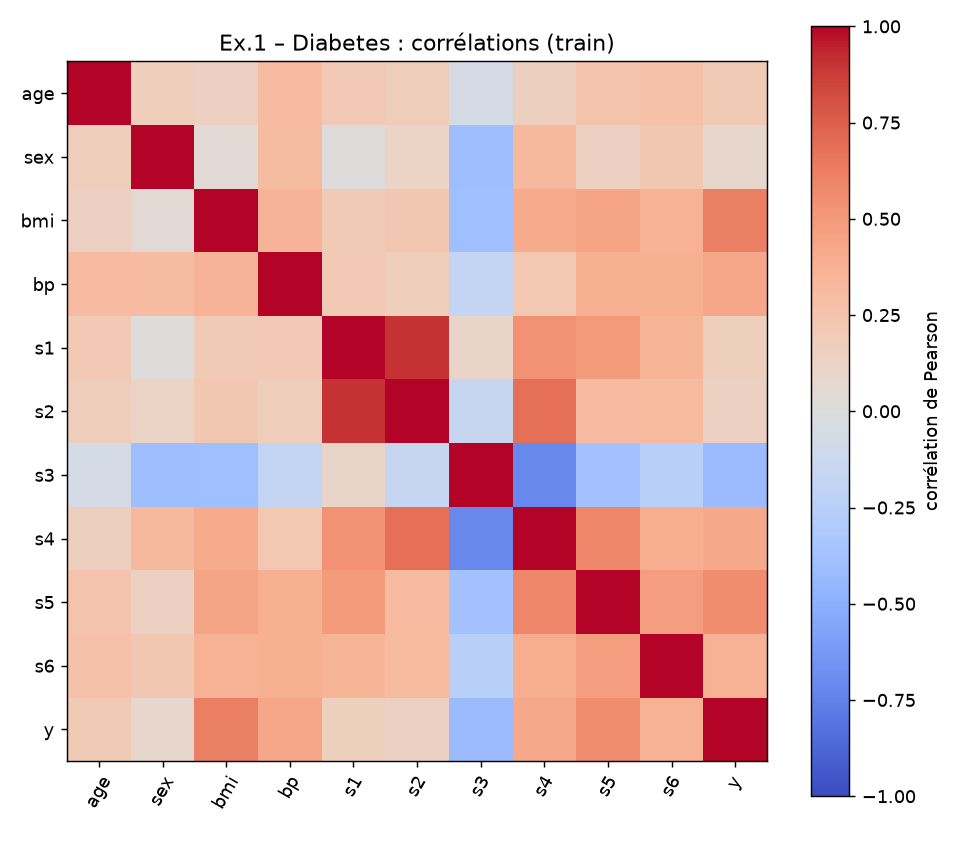

results/figures\ex1_diabetes_curves.png


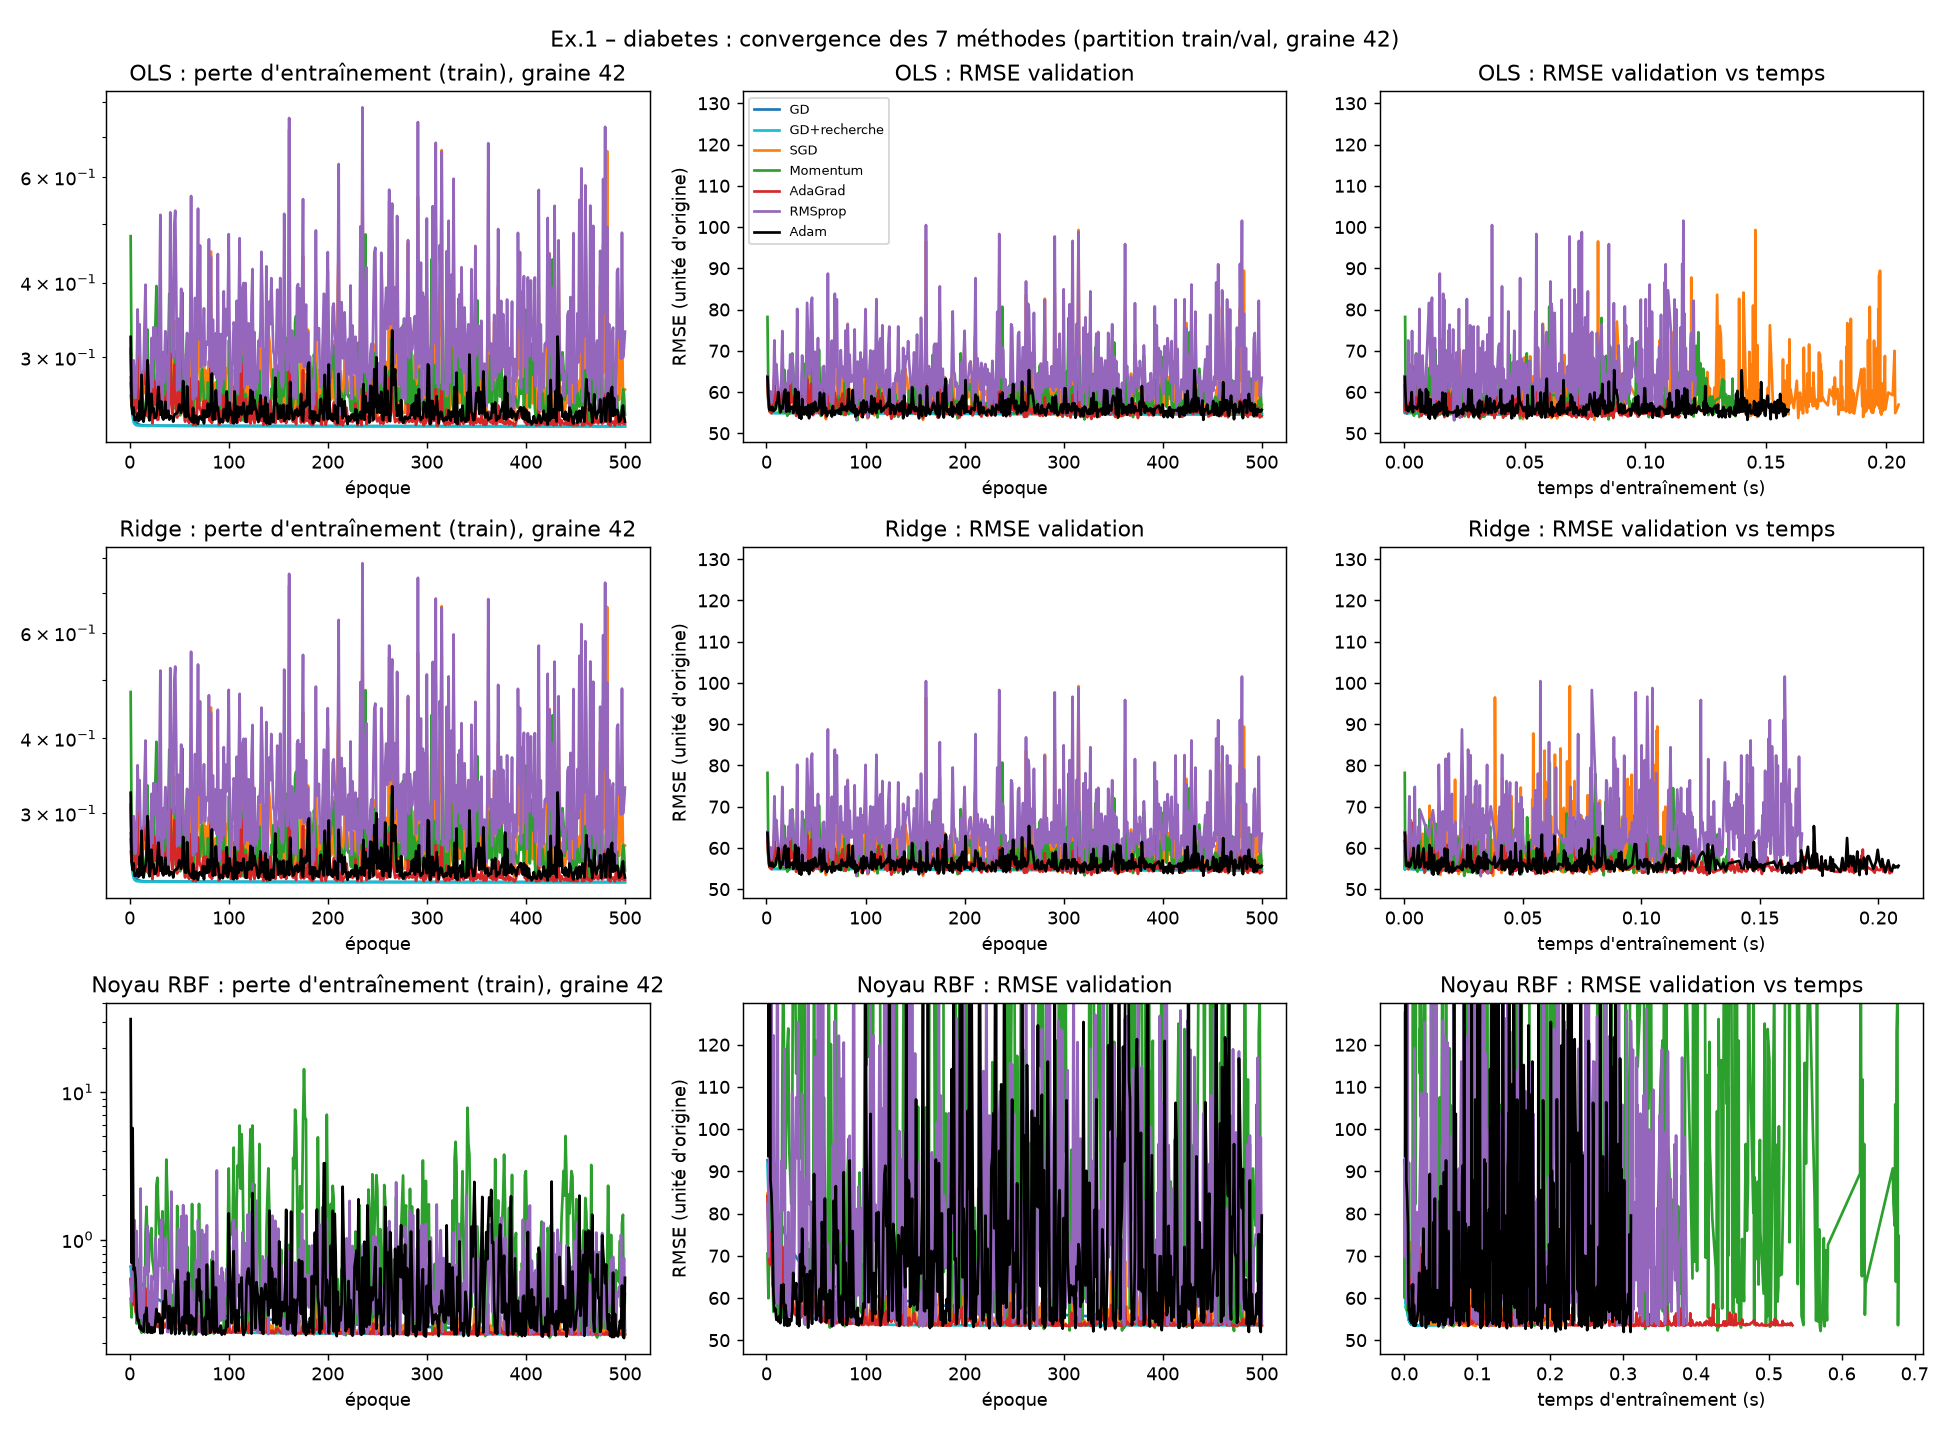

results/figures\ex1_diabetes_pred.png


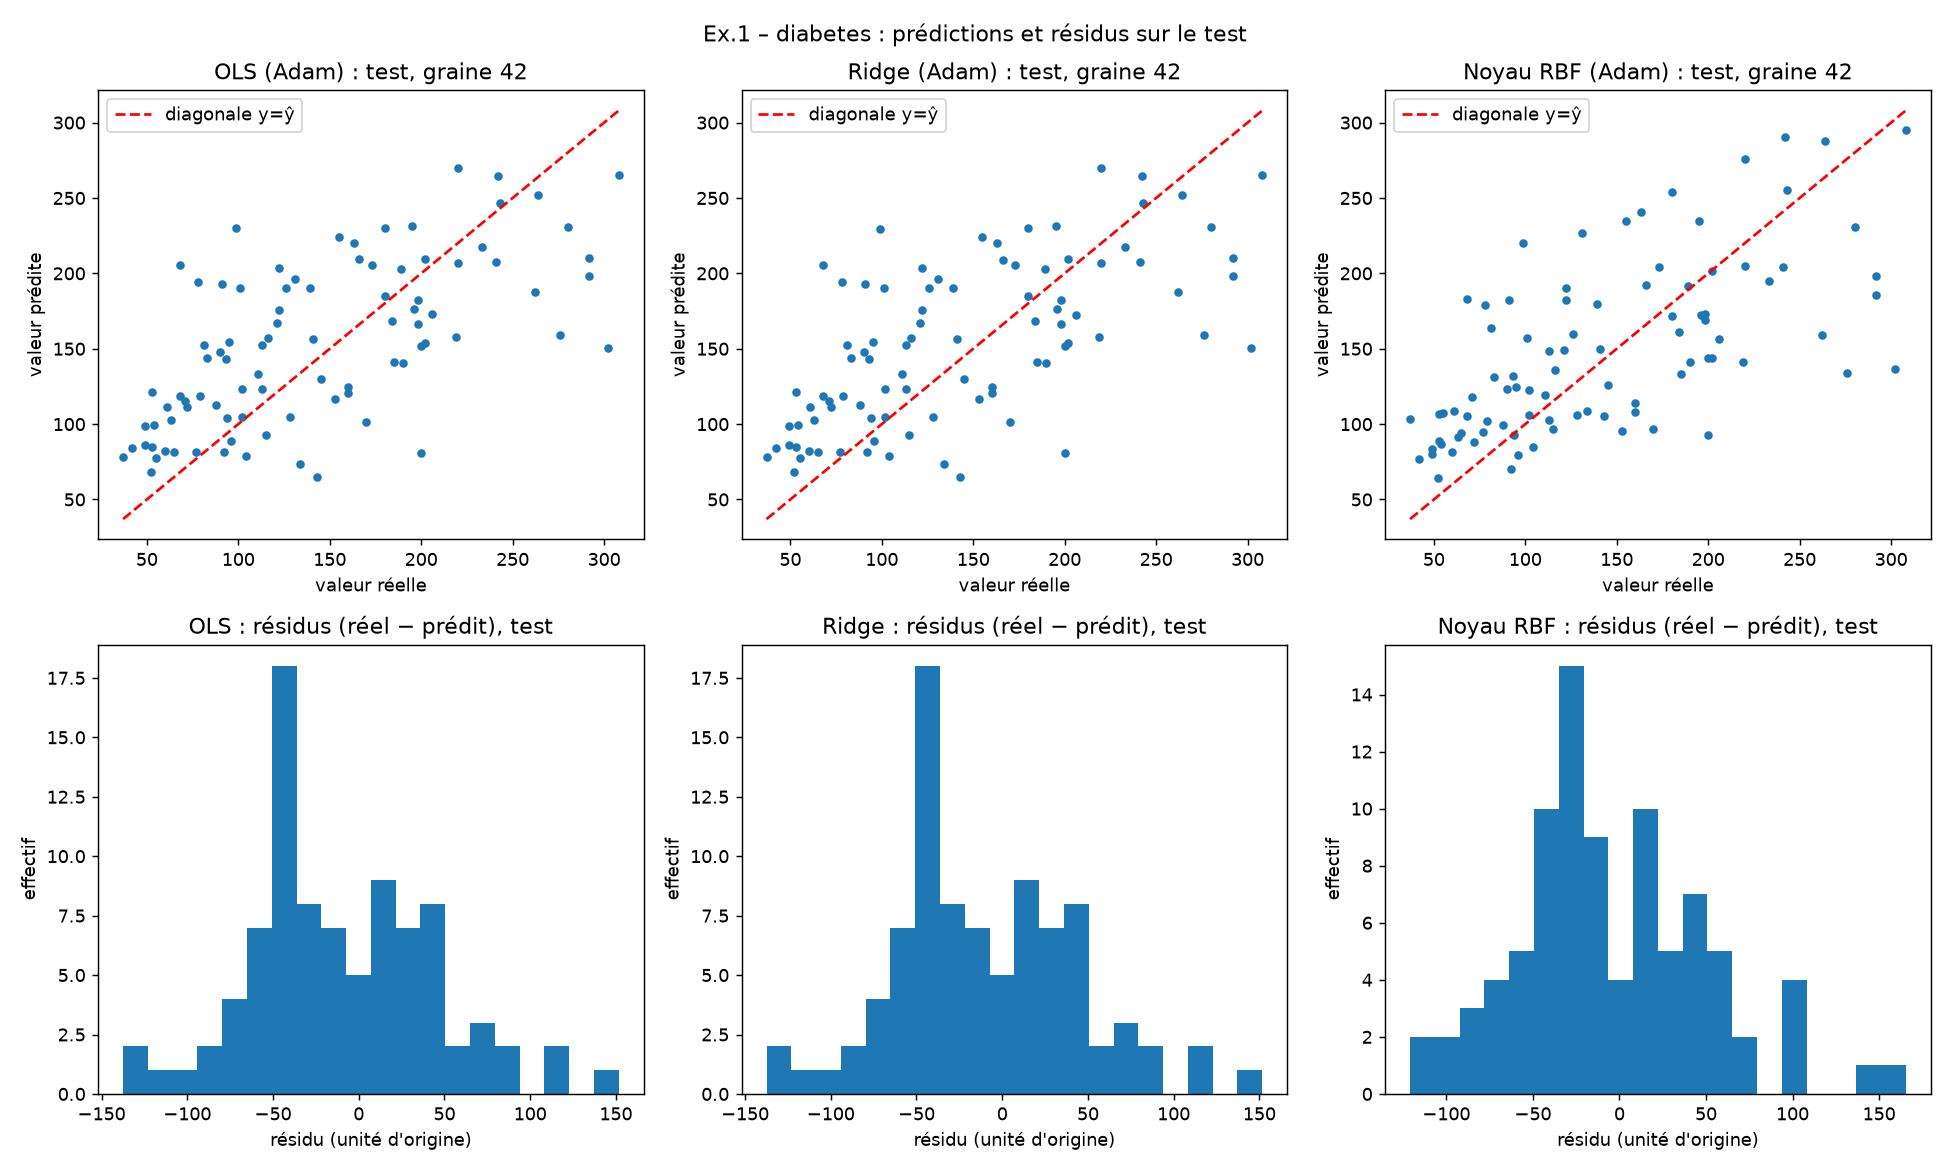

results/figures\ex1_nonlinear_curves.png


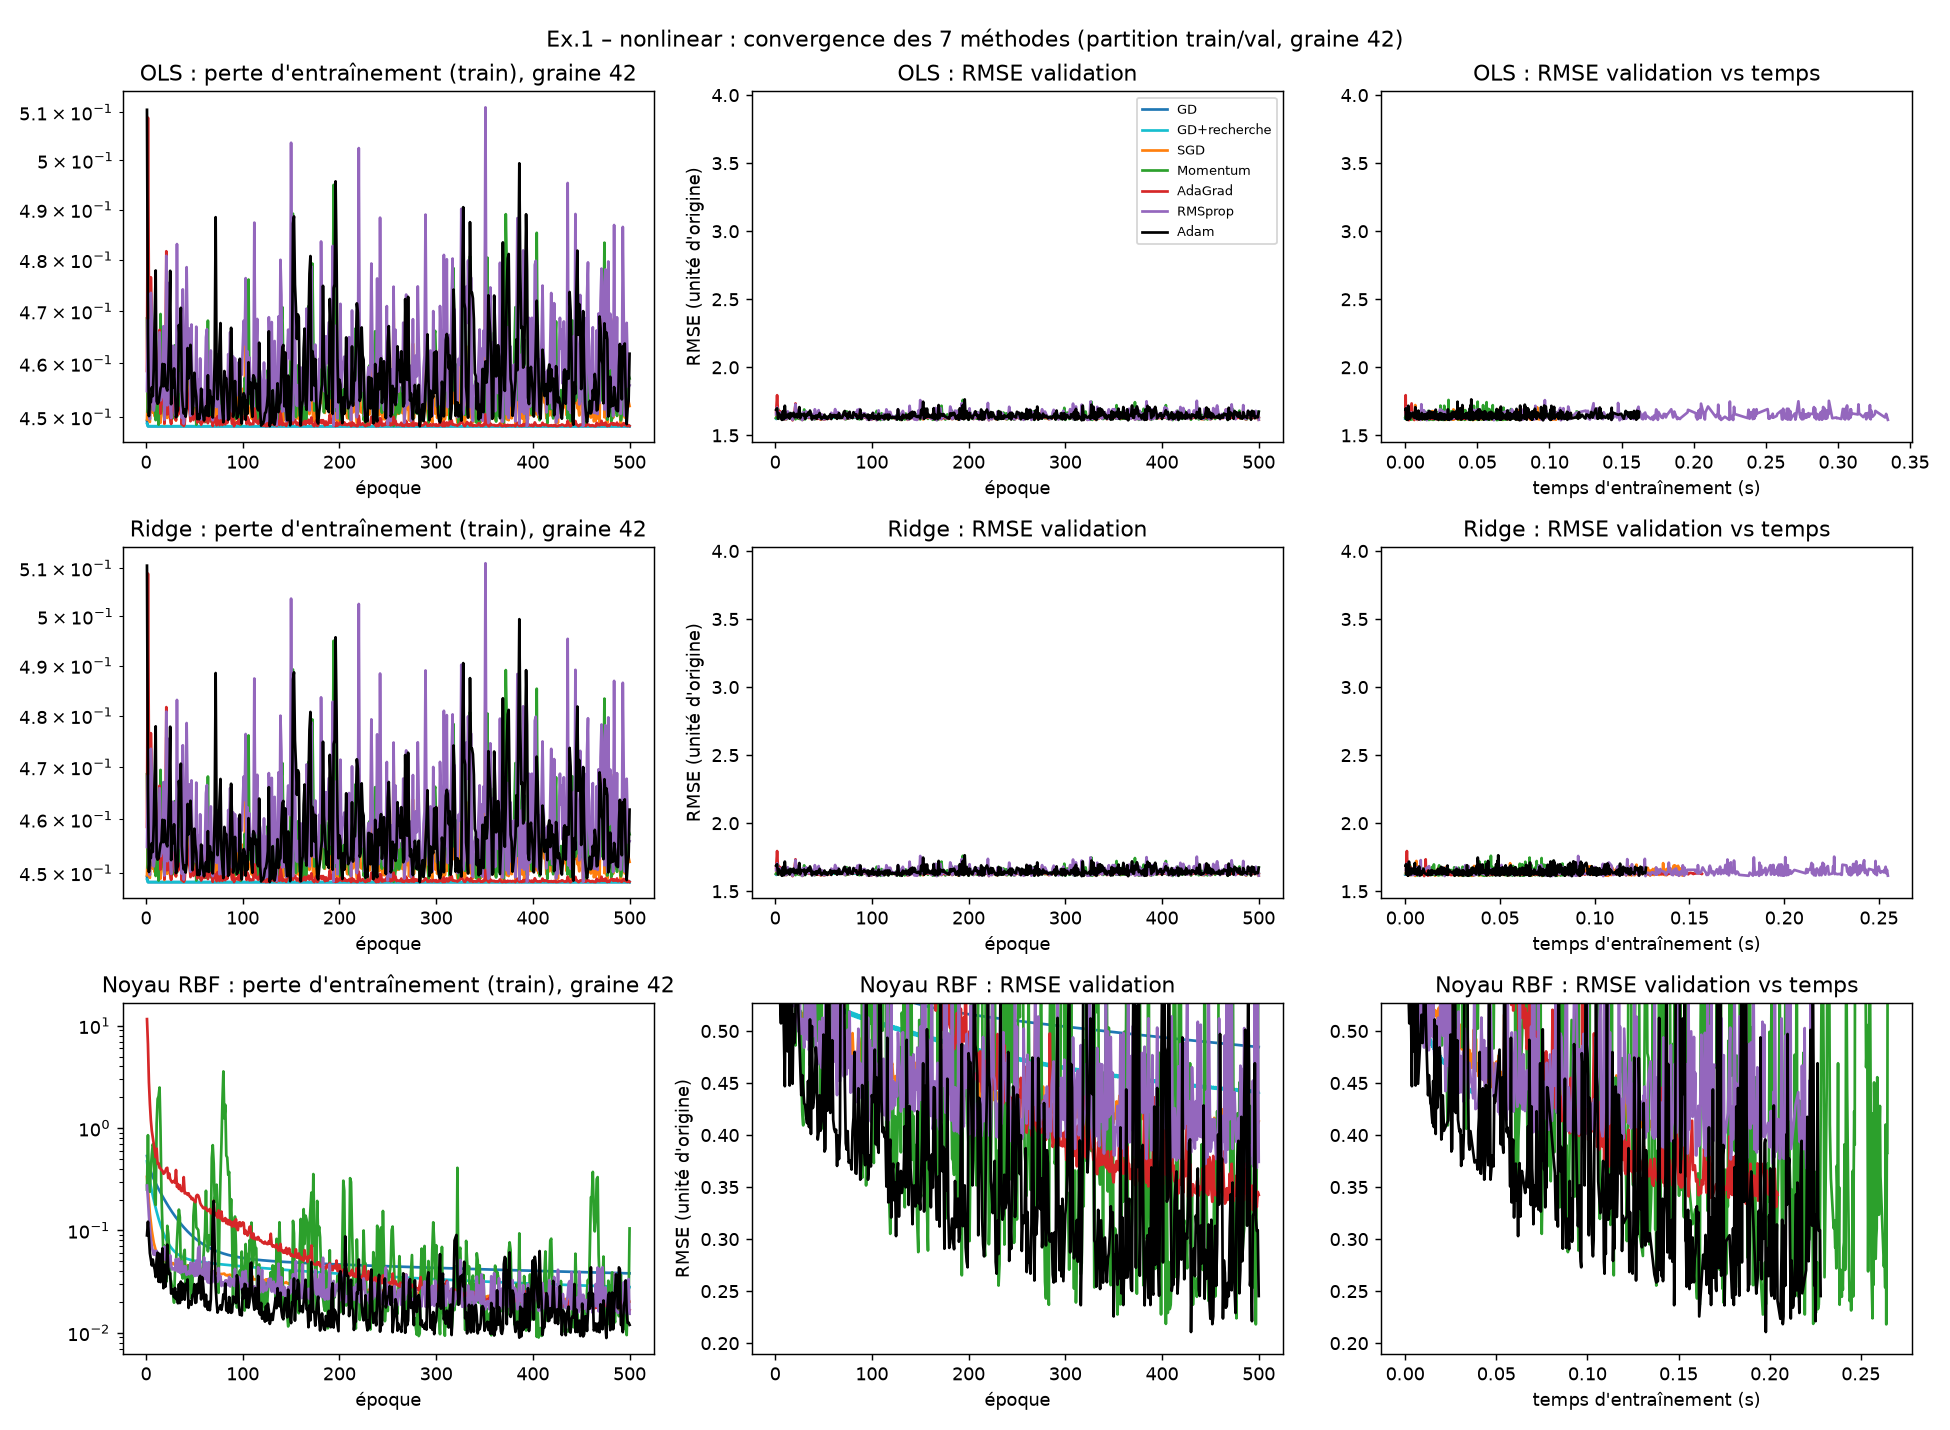

results/figures\ex1_nonlinear_pred.png


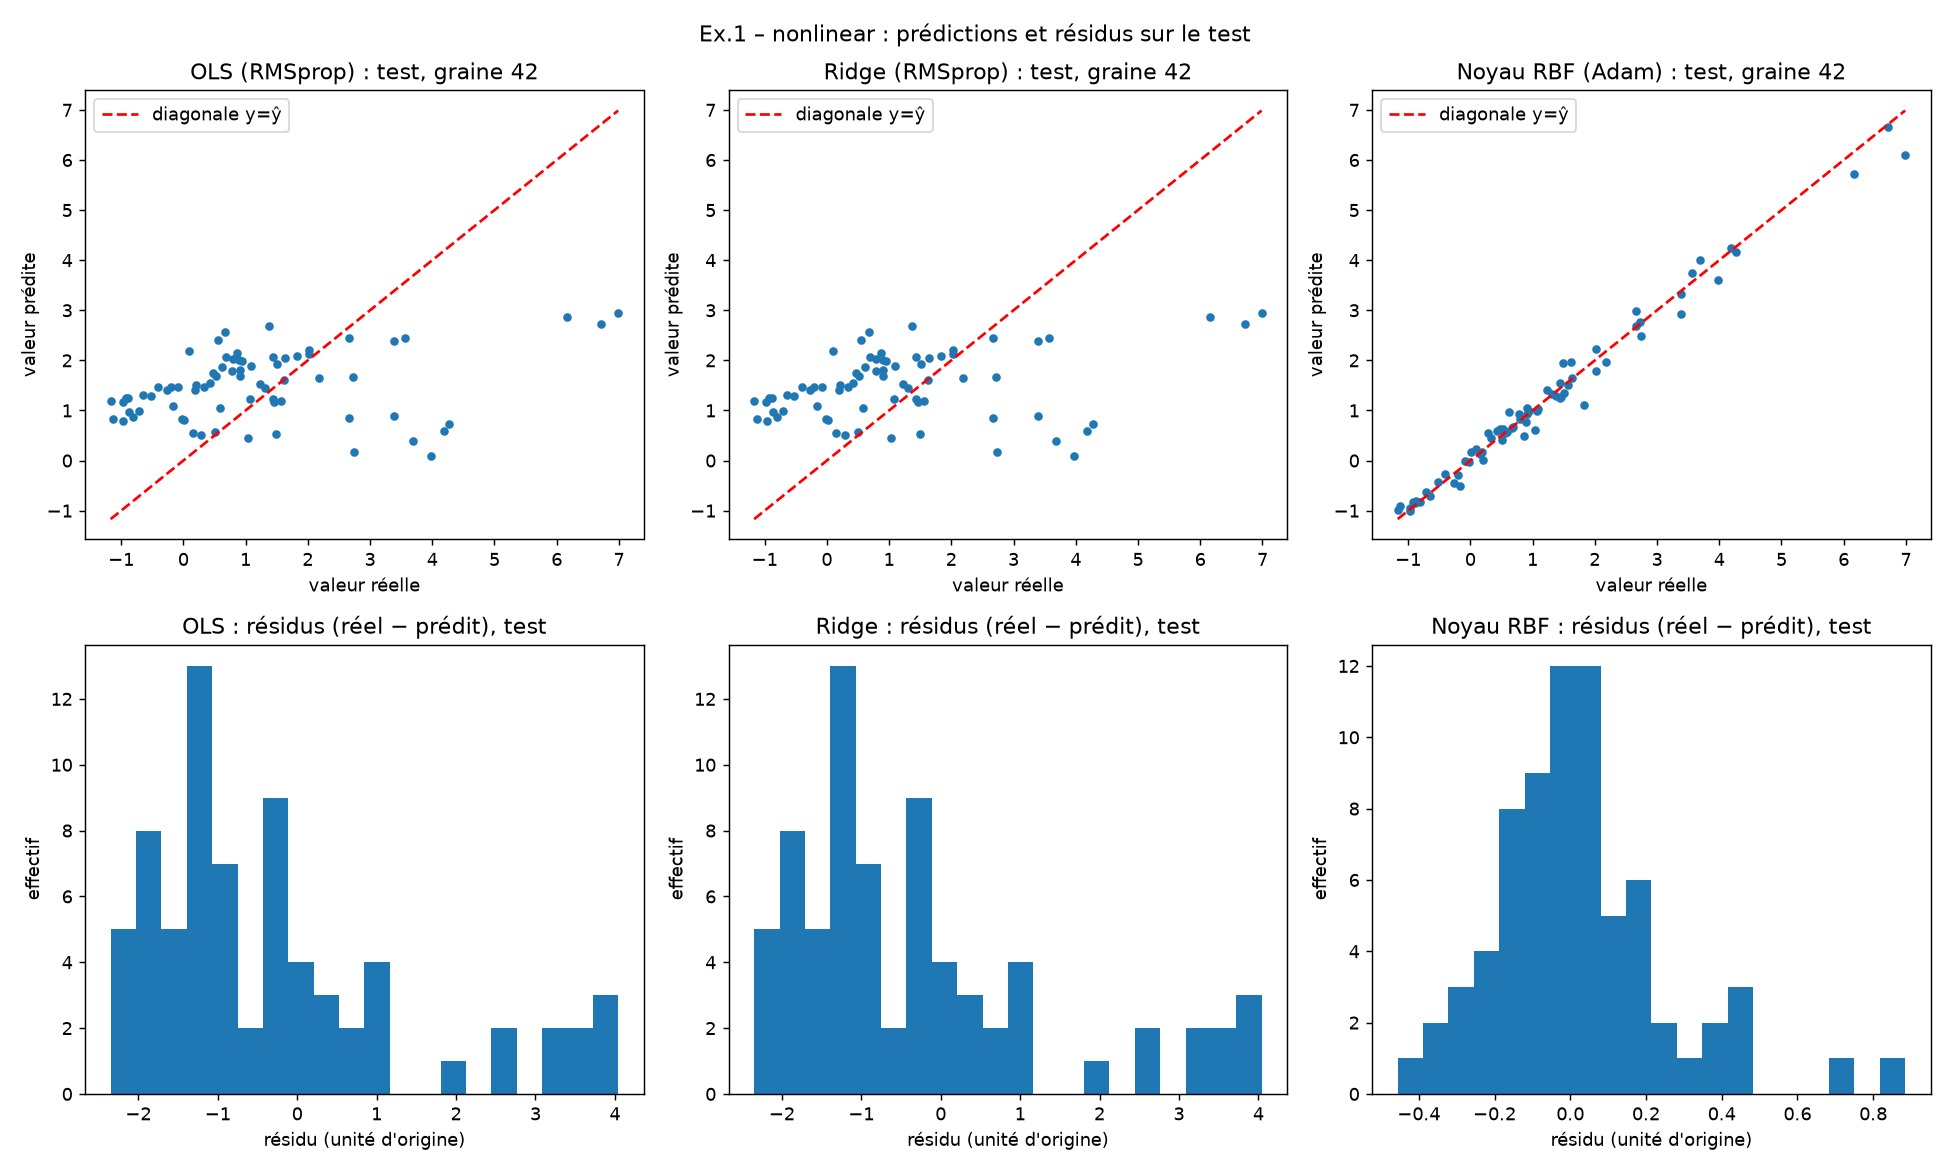

results/figures\ex1_nonlinear_surface.png


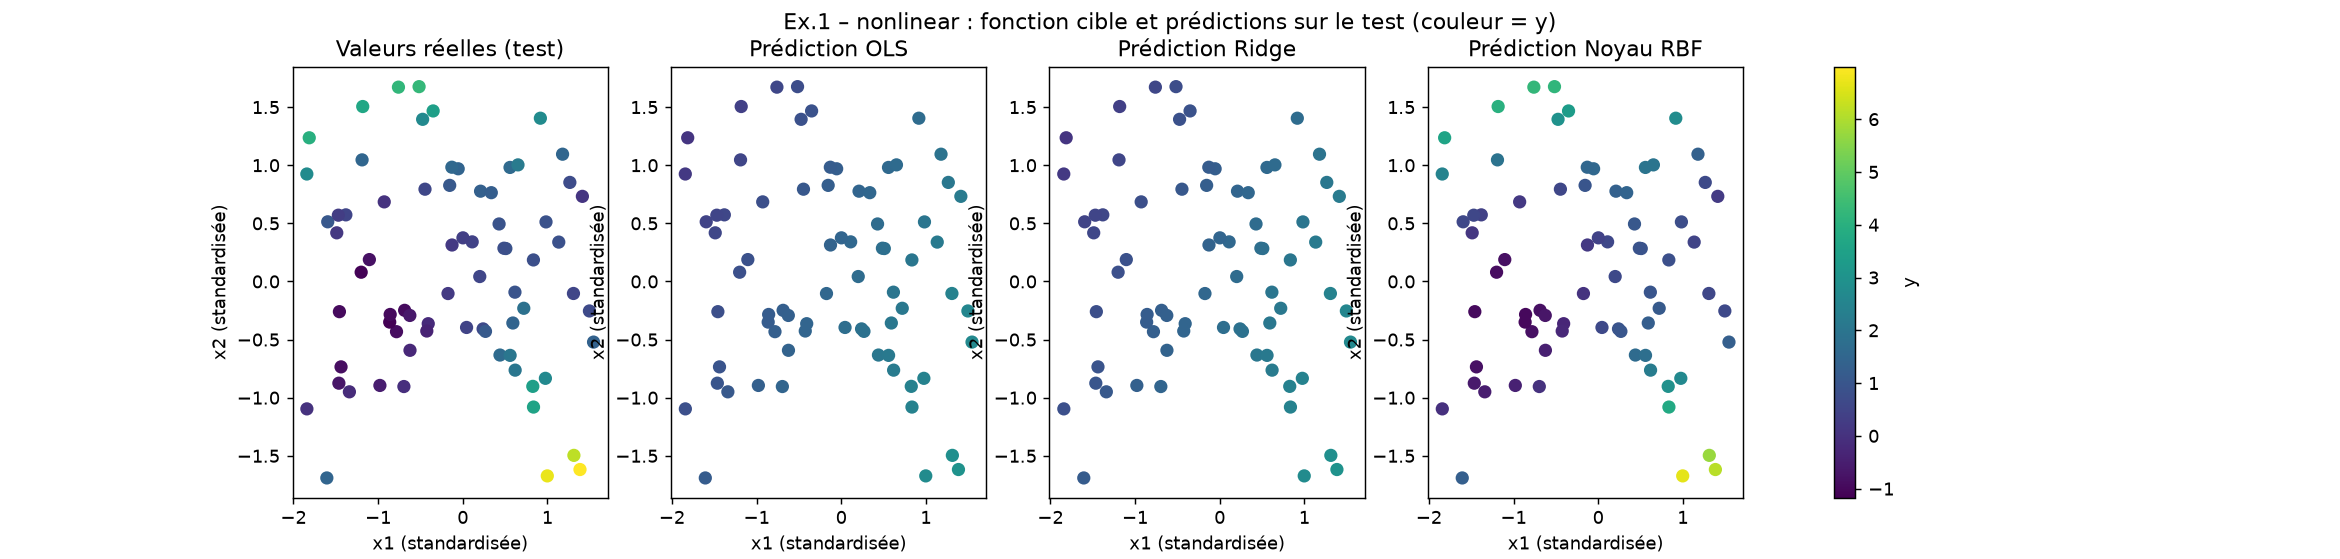

In [ ]:
import glob
from IPython.display import Image, display
for f in sorted(glob.glob("results/figures/ex1_*.png")):
    print(f); display(Image(filename=f, width=900))

## Export

In [ ]:
import shutil, os
shutil.make_archive("results", "zip", "results")
print("Créé :", os.path.abspath("results.zip"), "(%.1f Mo)" % (os.path.getsize("results.zip") / 1e6))

Créé : c:\Users\lenovo\Desktop\HADRI\results.zip (1.6 Mo)
